# Range-Based Volatility Estimation from Candlestick Data: Exact Simulation, Estimator Efficiency, and Jump Robustness

**Abstract.** A daily candlestick $(O, H, L, C)$ is a four-number summary of a continuous price path, and the standard close-to-close variance estimator reads only two of them. This notebook develops the statistics of the other two. We derive the exact conditional law of a Brownian path's extremes and use it to build a bar simulator with no discretization bias in the extremes; we quantify the bias of naively sampled bars (Beckers, 1983) and its consequences for estimator selection; we measure the efficiency of the four classical range-based estimators, obtaining $4.92\times$ (Parkinson), $7.47\times$ (Garman-Klass), and $6.06\times$ (Rogers-Satchell) relative to close-to-close, in agreement with asymptotic theory and against the folklore figure of $5.2\times$; we show Yang-Zhang's advertised $14\times$ ceiling realizes as $6.4\times$ in an empirically calibrated overnight regime; we convert efficiency into detection power and confirmation time; we derive, in closed form, the normalizing constant of the daily wick statistic $w = (H{-}L) - |O{-}C|$, namely $\mathbb{E}[w^2] = (4\ln 2 - 2)\,\sigma^2$, characterize its opposite behavior under permanent jumps versus flash crashes, and reproduce the robustness of its intraday-summed version (Li, Nolte, Nolte and Yu, 2025); finally we construct the minimum-variance unbiased linear combination of bar features, which attains $7.7\times$ efficiency out of sample, and close with an empirical application classifying the Nifty 50 index, Adani Enterprises, and Paytm (One 97 Communications) into distinct estimator regimes.

## 1. Model and Notation

Let the log price $X_t$ follow a Brownian motion with volatility $\sigma$ per day, $X_t = \sigma W_t$ on the unit interval $t \in [0,1]$ representing one session, with the open normalized to $X_0 = 0$. The bar records

$$r = X_1, \qquad h = \max_{t \le 1} X_t, \qquad l = \min_{t \le 1} X_t, \qquad R = h - l, \qquad w = R - |r|,$$

that is, the open-to-close return, the high and low in log distance from the open, the range, and the wick (the total shadow length). Where multi-day structure matters we write $o_t = \ln(O_t / C_{t-1})$ for the overnight gap. An estimator $\hat\sigma^2$ of the daily variance is **unbiased** if $\mathbb{E}[\hat\sigma^2] = \sigma^2$, and the **relative efficiency** of estimator $B$ against $A$ is $\mathrm{Var}(\hat\sigma^2_A) / \mathrm{Var}(\hat\sigma^2_B)$; since estimator variance scales as $1/n$ over $n$ independent days, efficiency is the factor by which required history shrinks at fixed precision.

Sections 3-4 construct an exact sampler for $(h, l, r)$. Sections 5-8 treat the classical estimators, their efficiency, their failure modes, and the detection problem. Sections 9-11 develop the wick statistic and the linear efficiency frontier. Section 12 applies the toolkit to roughly four and a half years of the Nifty 50 index, Adani Enterprises, and Paytm.

## 2. Environment

In [1]:
import base64, io, json, time, urllib.request, urllib.parse, zlib
import numpy as np
from scipy.stats import norm
from scipy import integrate
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5.0), "font.size": 11, "axes.titlesize": 12,
    "axes.labelsize": 11, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})
C_MAIN, C_ACCENT, C_MUTED, C_FOURTH = "#33415C", "#7F1D1D", "#9AA0A6", "#B08968"
C_SERIES = [C_MAIN, "#5F7470", C_ACCENT, C_FOURTH, C_MUTED]

FOURLN2 = 4 * np.log(2)                 # E[R^2]/sigma^2 (Feller, 1951)
LAM = FOURLN2 - 2                       # E[w^2]/sigma^2 (derived in Section 9)
GK_C = 2 * np.log(2) - 1

def chunk_stats(x, k=20):
    # Mean of x and the standard error of that mean, from k equal chunks
    m = len(x) - (len(x) % k)
    ch = x[:m].reshape(k, -1).mean(axis=1)
    return float(ch.mean()), float(ch.std(ddof=1) / np.sqrt(k))

def eff_stats(est, cc, k=20):
    # Efficiency Var(cc)/Var(est) with a chunked standard error
    m = len(est) - (len(est) % k)
    e = np.array([cc[i::k][:m // k].var() / est[i::k][:m // k].var()
                  for i in range(k)])
    return float(e.mean()), float(e.std(ddof=1) / np.sqrt(k))

print("numpy", np.__version__)

numpy 2.4.4


## 3. Distribution of the Extremes

### 3.1 The marginal maximum

For standard Brownian motion ($\sigma = 1$) the reflection principle pairs every path that touches level $y > 0$ and ends below $c \le y$ with its reflection after the first touch, which ends at $2y - c \ge y$. Both have equal probability, so

$$\mathbb{P}(M \ge y,\; W_1 \le c) = \mathbb{P}(W_1 \ge 2y - c), \qquad M = \max_{t\le 1} W_t. \tag{3.1}$$

Setting $c = y$ gives $\mathbb{P}(M \ge y) = 2\,\mathbb{P}(W_1 \ge y)$, i.e. $M \overset{d}{=} |W_1|$, the half-normal law. Its mean follows by direct integration,

$$\mathbb{E}[M] = \mathbb{E}|Z| = 2\int_0^\infty z\,\varphi(z)\,dz = 2\varphi(0) = \sqrt{2/\pi} \approx 0.79788,$$

and by the symmetry $\mathbb{E}[\min] = -\mathbb{E}[M]$ together with linearity of expectation (which requires no independence),

$$\mathbb{E}[R] = 2\sqrt{2/\pi}\,\sigma \approx 1.59577\,\sigma. \tag{3.2}$$

The second moment of the range requires the joint law of both extremes and was computed by Feller (1951):

$$\mathbb{E}[R^2] = 4\ln 2\cdot \sigma^2 \approx 2.77259\,\sigma^2. \tag{3.3}$$

Equations (3.2)-(3.3) serve as closed-form acceptance tests for every simulator below.

### 3.2 The joint law of maximum and close, and the conditional bridge maximum

Differentiating (3.1) in $c$ gives the joint density along the close, $\mathbb{P}(M \ge y,\, W_1 \in dc) = \varphi(2y - c)\,dc$ for $y \ge \max(0, c)$, and differentiating once more in $y$,

$$f_{M, W_1}(y, c) = 2\,(2y - c)\,\varphi(2y - c), \qquad y \ge \max(0, c). \tag{3.4}$$

Dividing by the marginal $\varphi(c)$ yields the survival function of the maximum **conditional on the endpoint**, the law of a Brownian bridge maximum:

$$\mathbb{P}(M \ge y \mid W_1 = c) = \frac{\varphi(2y-c)}{\varphi(c)} = \exp\!\big({-2y(y-c)}\big), \qquad y \ge \max(0,c), \tag{3.5}$$

and for a step of variance $s^2$ the exponent rescales to $-2y(y-c)/s^2$.

### 3.3 Exact sampling by inversion

Equating (3.5) to $U \sim \mathrm{Uniform}(0,1)$ and solving the quadratic $y^2 - cy + \tfrac{s^2}{2}\ln U = 0$ gives

$$M = \tfrac{1}{2}\Big(c + \sqrt{c^2 - 2 s^2 \ln U}\Big), \tag{3.6}$$

taking the larger root since $M \ge \max(0, c)$; the smaller root is discarded because $\ln U \le 0$ makes the discriminant at least $c^2$, placing the smaller root at or below $\min(0,c)$. The minimum is sampled from the mirrored formula with an independent uniform, since $-W$ is again a Brownian bridge with endpoint $-c$.

E[M]      sampler 0.79778 +/- 0.00039   theory 0.79788
E[M^2]    sampler 0.99948 +/- 0.00101   theory 1.00000


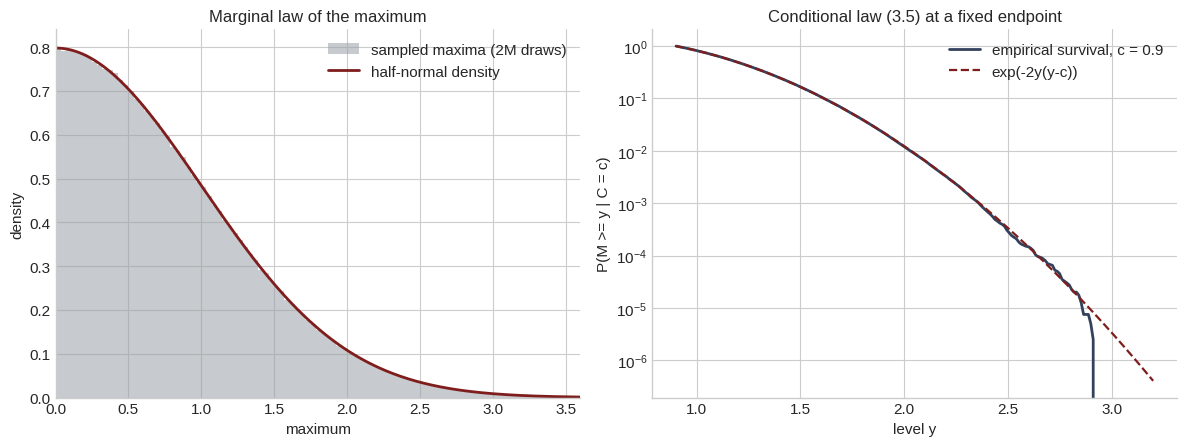

In [2]:
# Numerical confirmation of (3.5)-(3.6)
rng = np.random.default_rng(20260801)
N = 2_000_000

# (a) marginal: compose sampler with a normal endpoint; must recover |N(0,1)|
c = rng.normal(0.0, 1.0, N)
u = rng.uniform(size=N)
m = 0.5 * (c + np.sqrt(c * c - 2.0 * np.log(u)))
mean, se = chunk_stats(m)
print(f"E[M]      sampler {mean:.5f} +/- {se:.5f}   theory {np.sqrt(2/np.pi):.5f}")
mean2, se2 = chunk_stats(m * m)
print(f"E[M^2]    sampler {mean2:.5f} +/- {se2:.5f}   theory 1.00000")

# (b) conditional: fix the endpoint and compare the empirical survival with (3.5)
c0 = 0.9
u0 = rng.uniform(size=400_000)
m0 = 0.5 * (c0 + np.sqrt(c0 * c0 - 2.0 * np.log(u0)))
ys = np.linspace(c0, 3.2, 200)
emp = (m0[None, :] >= ys[:, None]).mean(axis=1)
theo = np.exp(-2 * ys * (ys - c0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
grid = np.linspace(0, 4, 300)
ax.hist(m, bins=160, density=True, color=C_MUTED, alpha=0.55,
        label="sampled maxima (2M draws)")
ax.plot(grid, 2 * norm.pdf(grid), color=C_ACCENT, lw=2,
        label="half-normal density")
ax.set_xlim(0, 3.6); ax.set_xlabel("maximum"); ax.set_ylabel("density")
ax.set_title("Marginal law of the maximum")
ax.legend()
ax = axes[1]
ax.semilogy(ys, emp, color=C_MAIN, lw=2, label="empirical survival, c = 0.9")
ax.semilogy(ys, theo, color=C_ACCENT, lw=1.6, ls="--", label="exp(-2y(y-c))")
ax.set_xlabel("level y"); ax.set_ylabel("P(M >= y | C = c)")
ax.set_title("Conditional law (3.5) at a fixed endpoint")
ax.legend()
plt.tight_layout(); plt.show()

## 4. Exact Bar Simulation and Discretization Bias

### 4.1 Algorithm

Divide the session into $m$ steps of variance $s^2 = \sigma^2/m$. Draw the increments $d_j$, form the running levels, and within each step sample the maximum and minimum from (3.6) and its mirror, conditioned on that step's endpoints; the bar's high and low are the extremes over steps. The construction is exact for the marginal law of each step's maximum and minimum. The single approximation is that the step's maximum and minimum use independent uniforms, whereas the true pair is (mildly) dependent within a step; the acceptance tests below bound the resulting bias at about $0.4\%$ of $\mathbb{E}[R^2]$ for $m = 2$ and below $0.1\%$ for $m \ge 8$. Because the bridge law (3.5) conditions on the endpoints, deterministic drift within a step alters only the endpoints, never the conditional law: the sampler is exact under arbitrary drift patterns at no extra cost.

### 4.2 Naive discretization

The naive alternative observes the path only at the $m$ grid points. Every observed extreme is then weakly inside the true one, so the observed range is biased short (Beckers, 1983), with the classical $O(1/\sqrt{m})$ boundary-crossing rate. Since real tapes print only at trades, an illiquid asset delivers naive bars by construction, a fact revisited in Section 7.

Acceptance tests against (3.2)-(3.3), 400k days per row
    m   E[R]/1.59577        E[R^2]/4ln2
    2    0.9997 +/- 0.0005      1.0030 +/- 0.0010


    8    1.0003 +/- 0.0005      1.0003 +/- 0.0010


   16    0.9997 +/- 0.0005      0.9997 +/- 0.0011


   64    0.9999 +/- 0.0006      0.9999 +/- 0.0012


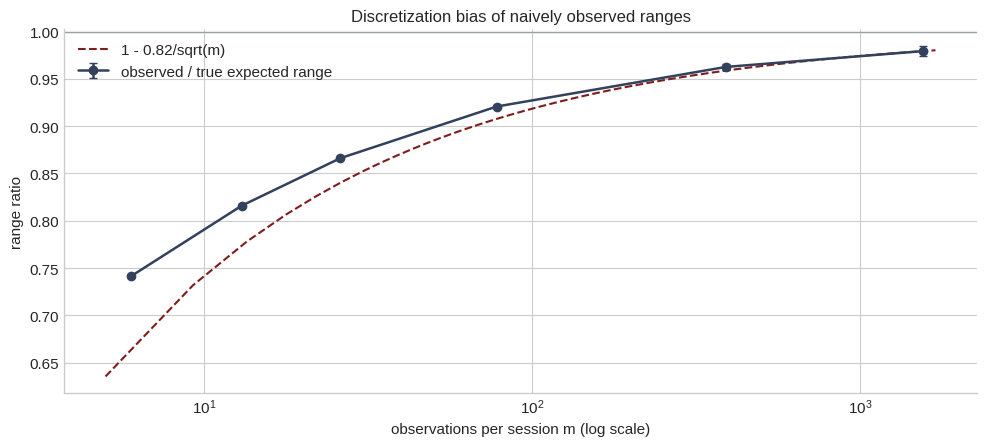

In [3]:
def bridge_max(c, s2, u):
    return 0.5 * (c + np.sqrt(c * c - 2.0 * s2 * np.log(u)))

def bridge_min(c, s2, v):
    return 0.5 * (c - np.sqrt(c * c - 2.0 * s2 * np.log(v)))

def exact_bar(rng, n_days, m, sigma, mu=0.0):
    s2 = sigma * sigma / m
    d = rng.normal(mu / m, np.sqrt(s2), size=(n_days, m))
    u = rng.uniform(size=(n_days, m))
    v = rng.uniform(size=(n_days, m))
    x = np.cumsum(d, axis=1)
    starts = x - d
    H = (starts + bridge_max(d, s2, u)).max(axis=1)
    L = (starts + bridge_min(d, s2, v)).min(axis=1)
    return H, L, x[:, -1]

def naive_bar(rng, n_days, m, sigma):
    d = rng.normal(0.0, sigma / np.sqrt(m), size=(n_days, m))
    x = np.cumsum(d, axis=1)
    return (np.maximum(x.max(axis=1), 0.0), np.minimum(x.min(axis=1), 0.0),
            x[:, -1])

rng = np.random.default_rng(7)
TRUE_ER = 2 * np.sqrt(2 / np.pi)

print("Acceptance tests against (3.2)-(3.3), 400k days per row")
print(f"{'m':>5} {'E[R]/1.59577':>14} {'E[R^2]/4ln2':>18}")
for m in (2, 8, 16, 64):
    H, L, C = exact_bar(rng, 400_000, m, 1.0)
    R = H - L
    r1, s1 = chunk_stats(R / TRUE_ER)
    r2, s2_ = chunk_stats(R * R / FOURLN2)
    print(f"{m:>5} {r1:>9.4f} +/- {s1:.4f} {r2:>11.4f} +/- {s2_:.4f}")

ms = np.array([6, 13, 26, 78, 390, 1560])
ratios, ses = [], []
for m in ms:
    n = int(min(200_000, 12_000_000 / m))
    H, L, C = naive_bar(rng, n, m, 1.0)
    r_, s_ = chunk_stats((H - L) / TRUE_ER)
    ratios.append(r_); ses.append(s_)
ratios, ses = np.array(ratios), np.array(ses)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.errorbar(ms, ratios, yerr=2 * ses, fmt="o-", color=C_MAIN, lw=1.8,
            capsize=3, label="observed / true expected range")
grid = np.linspace(5, 1700, 400)
beta = (1 - ratios[-1]) * np.sqrt(ms[-1])
ax.plot(grid, 1 - beta / np.sqrt(grid), color=C_ACCENT, ls="--", lw=1.5,
        label=f"1 - {beta:.2f}/sqrt(m)")
ax.axhline(1.0, color=C_MUTED, lw=1)
ax.set_xscale("log")
ax.set_xlabel("observations per session m (log scale)")
ax.set_ylabel("range ratio")
ax.set_title("Discretization bias of naively observed ranges")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Classical Estimators

With the notation of Section 1, the four classical estimators are

$$\hat\sigma^2_{P} = \frac{R^2}{4\ln 2}, \qquad
\hat\sigma^2_{GK} = \tfrac{1}{2}R^2 - (2\ln 2 - 1)\,r^2, \qquad
\hat\sigma^2_{RS} = h(h - r) + l(l - r),$$

$$\hat\sigma^2_{YZ} = V_o + k\,V_r + (1-k)\,\overline{RS}, \qquad
k = \frac{0.34}{1.34 + \frac{n+1}{n-1}},$$

where $V_o, V_r$ are $ddof{=}1$ sample variances of overnight and open-to-close returns over an $n$-day window and $\overline{RS}$ is the window mean of the daily Rogers-Satchell values (Parkinson, 1980; Garman and Klass, 1980; Rogers and Satchell, 1991; Yang and Zhang, 2000).

**Unbiasedness.** Parkinson's follows directly from (3.3). For Garman-Klass, using (3.3) and $\mathbb{E}[r^2] = \sigma^2$,

$$\mathbb{E}\big[\tfrac{1}{2}R^2 - (2\ln 2 - 1) r^2\big]
 = \tfrac{1}{2}\,4\ln 2\,\sigma^2 - (2\ln 2 - 1)\,\sigma^2 = \sigma^2,$$

and the specific weights minimize the variance among unbiased combinations of $R^2$ and $r^2$ (Garman and Klass, 1980). Rogers and Satchell (1991) prove $\mathbb{E}[\hat\sigma^2_{RS}] = \sigma^2$ for Brownian motion with **arbitrary drift** $\mu$; both overshoot factors $h - r$ and $-l$ vanish on a monotone path, which is the mechanism by which the corridor is attributed to drift. The table below verifies the drift behavior of all four numerically.

In [4]:
def parkinson_var(h, l):
    R = h - l
    return R * R / FOURLN2

def gk_var(h, l, r):
    R = h - l
    return 0.5 * R * R - GK_C * r * r

def rs_var(h, l, r):
    return h * (h - r) + l * (l - r)

def wick_var(h, l, r, lam=LAM):
    w = (h - l) - np.abs(r)
    return w * w / lam

rng = np.random.default_rng(11)
print("E[estimate]/sigma^2 under drift (400k days per cell, m=16, +/- 2 SE)")
print(f"{'mu/sigma':>9} {'close pair':>13} {'Parkinson':>13} "
      f"{'Garman-Klass':>13} {'Rogers-Satchell':>16}")
for mu in (0.0, 0.5, 1.0, 2.0):
    H, L, C = exact_bar(rng, 400_000, 16, 1.0, mu=mu)
    row = []
    for est in (C * C, parkinson_var(H, L), gk_var(H, L, C), rs_var(H, L, C)):
        m_, s_ = chunk_stats(est)
        row.append(f"{m_:6.3f}+/-{2*s_:.3f}")
    print(f"{mu:>9.1f} " + " ".join(f"{x:>13}" for x in row[:3])
          + f" {row[3]:>16}")

E[estimate]/sigma^2 under drift (400k days per cell, m=16, +/- 2 SE)
 mu/sigma    close pair     Parkinson  Garman-Klass  Rogers-Satchell


      0.0  0.999+/-0.004  1.000+/-0.002  1.000+/-0.001    1.001+/-0.002


      0.5  1.249+/-0.005  1.094+/-0.002  1.034+/-0.001    0.999+/-0.002


      1.0  1.996+/-0.008  1.375+/-0.003  1.135+/-0.002    0.999+/-0.002


      2.0  4.999+/-0.010  2.486+/-0.003  1.516+/-0.002    0.999+/-0.002


## 6. Efficiency Under Ideal Conditions and Under Gaps

### 6.1 The clean-day benchmark

All estimators observe the same simulated days, so sampling noise is common and efficiency ratios are estimated far more precisely than either variance alone. The asymptotic benchmark for Parkinson is $2/\Lambda$ with $\Lambda \approx 0.4073$ the range-statistic variance constant (Christensen and Podolskij, 2007), i.e. $4.91$; the commonly quoted $5.2$ is not supported.

### 6.2 Yang-Zhang under an empirical overnight share

Yang-Zhang's ceiling of $14\times$ obtains in a boundary case. We evaluate it at a representative overnight variance share, $f \approx 0.3$ (broadly consistent with the 14-42% range measured across the three assets in Section 12), with $n = 20$ day windows against the close-to-close sample variance over the same windows.

Single-day efficiency vs close pair (1.2M days, +/- 2 SE)
  Parkinson       :  4.91 +/- 0.02
  Garman-Klass    :  7.46 +/- 0.05
  Rogers-Satchell :  6.06 +/- 0.05
  wick            :  2.77 +/- 0.02
  Parkinson asymptotic reference 2/0.4073 = 4.91


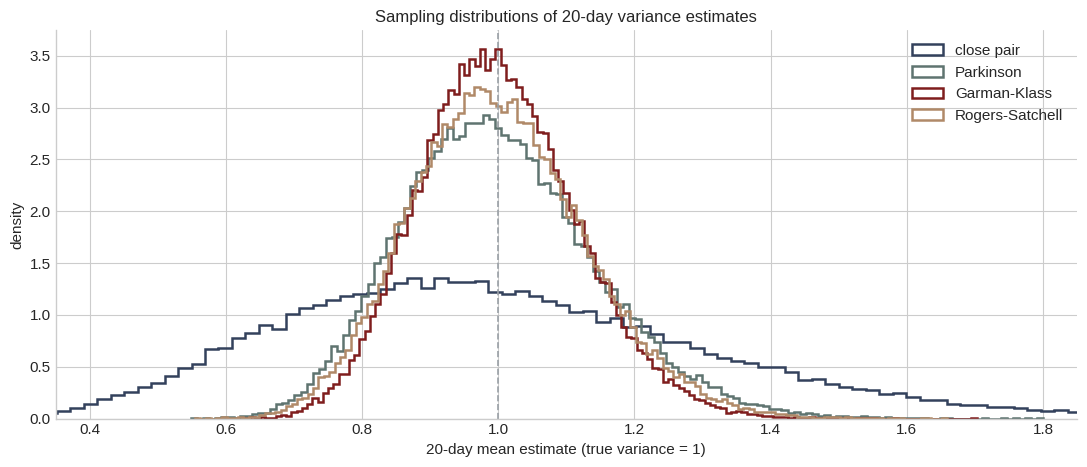

Yang-Zhang, 30% overnight share, n=20: E = 1.0001 +/- 0.0010,  efficiency 6.36 +/- 0.09   (advertised ceiling: 14)


In [5]:
rng = np.random.default_rng(13)
NW, ND = 60_000, 20
H, L, C = exact_bar(rng, NW * ND, 16, 1.0)

daily = {"close pair": C * C, "Parkinson": parkinson_var(H, L),
         "Garman-Klass": gk_var(H, L, C), "Rogers-Satchell": rs_var(H, L, C),
         "wick": wick_var(H, L, C)}
cc = daily["close pair"]
print("Single-day efficiency vs close pair (1.2M days, +/- 2 SE)")
for name, est in daily.items():
    if name == "close pair":
        continue
    e, se = eff_stats(est, cc)
    print(f"  {name:16}: {e:5.2f} +/- {2*se:.2f}")
print(f"  Parkinson asymptotic reference 2/0.4073 = {2/0.4073:.2f}")

fig, ax = plt.subplots(figsize=(11, 4.8))
for (name, est), col in zip(list(daily.items())[:4], C_SERIES):
    means = est.reshape(NW, ND).mean(axis=1)
    ax.hist(means, bins=140, density=True, histtype="step", lw=1.8,
            color=col, label=name)
ax.axvline(1.0, color=C_MUTED, ls="--", lw=1.2)
ax.set_xlim(0.35, 1.85)
ax.set_xlabel("20-day mean estimate (true variance = 1)")
ax.set_ylabel("density")
ax.set_title("Sampling distributions of 20-day variance estimates")
ax.legend()
plt.tight_layout(); plt.show()

# Yang-Zhang in the empirical gap regime
sig_r, sig_o = np.sqrt(0.7), np.sqrt(0.3)
H, L, C = exact_bar(rng, NW * ND, 8, sig_r)
Hw, Lw, Cw = H.reshape(NW, ND), L.reshape(NW, ND), C.reshape(NW, ND)
ow = rng.normal(0.0, sig_o, size=(NW, ND))
K = 0.34 / (1.34 + (ND + 1) / (ND - 1))
yz = (ow.var(axis=1, ddof=1) + K * Cw.var(axis=1, ddof=1)
      + (1 - K) * rs_var(Hw, Lw, Cw).mean(axis=1))
cc_n = (ow + Cw).var(axis=1, ddof=1)
e, se = eff_stats(yz, cc_n)
m_, s_ = chunk_stats(yz)
print(f"Yang-Zhang, 30% overnight share, n=20: E = {m_:.4f} +/- {2*s_:.4f},"
      f"  efficiency {e:.2f} +/- {2*se:.2f}   (advertised ceiling: 14)")

## 7. Discretization Bias and the MSE Crossover

After averaging $n$ days, an estimator with per-day bias $b$ and variance $V$ has

$$\mathrm{MSE}(n) = b^2 + V/n,$$

since averaging shrinks variance but leaves systematic bias intact. For an unbiased competitor with variance $V_u$, equating the two MSE curves gives the day the lead changes,

$$n^* = \frac{V_u - V_b}{b^2}. \tag{7.1}$$

On naively observed bars at 13 prints per session, Parkinson's variance-efficiency *improves* (the shortened ranges cluster tighter) while a bias of about $-0.30\,\sigma^2$ appears; (7.1) then bounds the useful life of that apparent superiority.

naive-bar Parkinson, m=13: bias -0.3027 +/- 0.0012, variance 0.3080
apparent efficiency 6.52 +/- 0.02  (exceeds the true-bar 4.92)
crossover (7.1): close-to-close overtakes after n* = 18.5 days


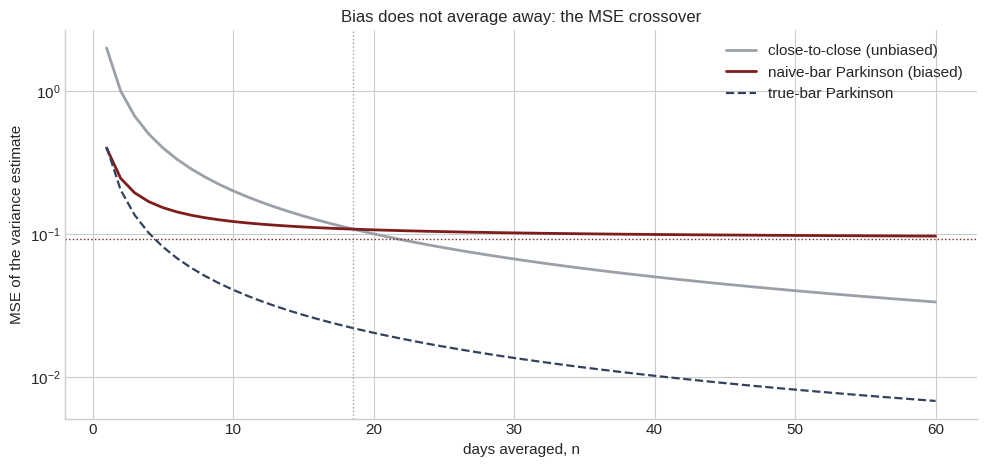

In [6]:
rng = np.random.default_rng(9)
H, L, C = naive_bar(rng, 800_000, 13, 1.0)
P13 = parkinson_var(H, L)
cc13 = C * C
b, seb = chunk_stats(P13 - 1.0)
vP = P13.var()
vcc = cc13.var()
e13, se13 = eff_stats(P13, cc13)
nstar = (vcc - vP) / (b * b)
print(f"naive-bar Parkinson, m=13: bias {b:+.4f} +/- {2*seb:.4f},"
      f" variance {vP:.4f}")
print(f"apparent efficiency {e13:.2f} +/- {2*se13:.2f}"
      f"  (exceeds the true-bar 4.92)")
print(f"crossover (7.1): close-to-close overtakes after n* = {nstar:.1f} days")

ns = np.arange(1, 61)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(ns, vcc / ns, color=C_MUTED, lw=2, label="close-to-close (unbiased)")
ax.plot(ns, b * b + vP / ns, color=C_ACCENT, lw=2,
        label="naive-bar Parkinson (biased)")
ax.plot(ns, 0.4073 / ns, color=C_MAIN, lw=1.6, ls="--",
        label="true-bar Parkinson")
ax.axhline(b * b, color=C_ACCENT, ls=":", lw=1)
ax.axvline(nstar, color=C_MUTED, ls=":", lw=1)
ax.set_yscale("log")
ax.set_xlabel("days averaged, n")
ax.set_ylabel("MSE of the variance estimate")
ax.set_title("Bias does not average away: the MSE crossover")
ax.legend()
plt.tight_layout(); plt.show()

## 8. Detection: Efficiency as Time

A volatility alarm is a sequential hypothesis test. Fix the false-alarm rate $\alpha$ by placing the threshold at the $(1-\alpha)$ quantile of the calm regime's rolling-estimate distribution; power against a given regime change is then determined by the estimator's precision. For a rolling mean of $n$ per-day estimates with variance $V$, a change from variance $v_0$ to $v_1$ is resolved at $z$ standard errors once $|v_1 - v_0| > z\sqrt{V/n}$, i.e. after

$$n^* = \frac{z^2\,V}{(v_1 - v_0)^2} \tag{8.1}$$

days. $V$ enters linearly: efficiency converts one-for-one into confirmation time.

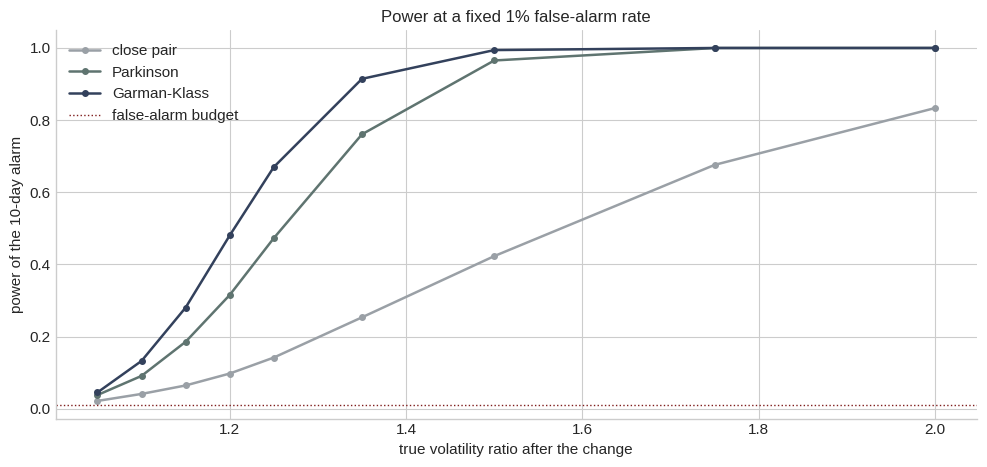

confirm 1.5x variance at z=2:  close pair   32.0 d   Garman-Klass  4.28 d
confirm 2.0x variance at z=2:  close pair    8.0 d   Garman-Klass  1.07 d


In [7]:
rng = np.random.default_rng(10)
NWC, ND = 40_000, 10
H, L, C = exact_bar(rng, NWC * ND, 8, 1.0)
calm = {"close pair": (C * C).reshape(NWC, ND).mean(axis=1),
        "Parkinson": parkinson_var(H, L).reshape(NWC, ND).mean(axis=1),
        "Garman-Klass": gk_var(H, L, C).reshape(NWC, ND).mean(axis=1)}
thr = {k: np.quantile(v, 0.99) for k, v in calm.items()}

ratios = np.array([1.05, 1.1, 1.15, 1.2, 1.25, 1.35, 1.5, 1.75, 2.0])
NWS = 12_000
power = {k: [] for k in thr}
for rho in ratios:
    H, L, C = exact_bar(rng, NWS * ND, 8, rho)
    sh = {"close pair": (C * C).reshape(NWS, ND).mean(axis=1),
          "Parkinson": parkinson_var(H, L).reshape(NWS, ND).mean(axis=1),
          "Garman-Klass": gk_var(H, L, C).reshape(NWS, ND).mean(axis=1)}
    for k in thr:
        power[k].append((sh[k] > thr[k]).mean())

fig, ax = plt.subplots(figsize=(10, 4.8))
for (k, vals), col in zip(power.items(), [C_MUTED, "#5F7470", C_MAIN]):
    ax.plot(ratios, vals, "o-", color=col, lw=1.8, ms=4, label=k)
ax.axhline(0.01, color=C_ACCENT, ls=":", lw=1, label="false-alarm budget")
ax.set_xlabel("true volatility ratio after the change")
ax.set_ylabel("power of the 10-day alarm")
ax.set_title("Power at a fixed 1% false-alarm rate")
ax.legend()
plt.tight_layout(); plt.show()

V_cc, V_gk = 2.0, 2.0 / 7.47
for v1 in (1.5, 2.0):
    print(f"confirm {v1:.1f}x variance at z=2:  close pair "
          f"{4*V_cc/(v1-1)**2:6.1f} d   Garman-Klass {4*V_gk/(v1-1)**2:5.2f} d")

## 9. The Wick Statistic and Its Constant

### 9.1 Definition and cancellation

The wick $w = R - |r| \ge 0$ removes the bar's net displacement from its total span. Any one-directional component, trend or permanent jump, enters $R$ and $|r|$ nearly equally and cancels; a displacement-free round trip (a flash crash) enters $R$ only, and survives in full. Both behaviors are quantified in Section 10.

### 9.2 The normalizing constant in closed form

The estimator requires $\lambda = \mathbb{E}[w^2]/\sigma^2$. Expanding with $\sigma = 1$,

$$\mathbb{E}[w^2] = \mathbb{E}[R^2] - 2\,\mathbb{E}[R\,|r|] + \mathbb{E}[r^2]
= 4\ln 2 - 2\,\mathbb{E}[R\,|r|] + 1,$$

so the one unknown is $\mathbb{E}[R\,|r|]$. By the symmetry $(\min, W_1) \overset{d}{=} (-M, -W_1)$ we have $\mathbb{E}[\min \cdot |W_1|] = -\mathbb{E}[M\,|W_1|]$, hence $\mathbb{E}[R\,|r|] = 2\,\mathbb{E}[M\,|W_1|]$, and the joint density (3.4) reduces the problem to a two-dimensional Gaussian integral:

$$\mathbb{E}[M\,|W_1|] = \int_{-\infty}^{\infty} |c| \int_{\max(0,c)}^{\infty} y\; 2(2y - c)\,\varphi(2y - c)\; dy\, dc.$$

Substitute $u = 2y - c$ (so $y = (u+c)/2$, $dy = du/2$, and the region $y \ge \max(0,c)$ becomes $u \ge |c|$):

$$\mathbb{E}[M\,|W_1|] = \int_{-\infty}^{\infty} \frac{|c|}{2} \int_{|c|}^{\infty} (u + c)\, u\, \varphi(u)\, du\, dc.$$

The inner integral splits into two standard pieces, $\int_a^\infty u^2\varphi(u)\,du = a\varphi(a) + Q(a)$ and $\int_a^\infty u\varphi(u)\,du = \varphi(a)$ with $Q = 1 - \Phi$, giving inner value $|c|\varphi(|c|) + Q(|c|) + c\,\varphi(|c|)$ at $a = |c|$. The term $\tfrac{|c|}{2}\,c\,\varphi(|c|)$ is odd in $c$ and integrates to zero; the even remainder doubles over $c > 0$:

$$\mathbb{E}[M\,|W_1|] = \int_0^{\infty} c^2 \varphi(c)\, dc + \int_0^{\infty} c\, Q(c)\, dc
= \frac{1}{2} + \left[\frac{c^2}{2} Q(c)\right]_0^\infty + \int_0^\infty \frac{c^2}{2}\varphi(c)\, dc = \frac{1}{2} + 0 + \frac{1}{4} = \frac{3}{4},$$

using integration by parts with $Q'(c) = -\varphi(c)$ in the last step. Therefore $\mathbb{E}[R\,|r|] = \tfrac{3}{2}$ and

$$\boxed{\;\lambda = 4\ln 2 - 2 \;=\; 0.7725887\ldots\;}, \qquad \hat\sigma^2_w = \frac{w^2}{\lambda}. \tag{9.1}$$

The cell below confirms (9.1) three independent ways: Monte Carlo on exact bars, direct quadrature of the double integral, and the closed form.

In [8]:
# (a) Monte Carlo
rng = np.random.default_rng(5)
H, L, C = exact_bar(rng, 1_000_000, 16, 1.0)
w = (H - L) - np.abs(C)
lam_mc, lam_se = chunk_stats(w * w)

# (b) direct quadrature of E[M |W1|] via the joint density (3.4)
def integrand(y, c):
    return y * abs(c) * 2 * (2 * y - c) * norm.pdf(2 * y - c)
q_neg, _ = integrate.dblquad(integrand, -8, 0, lambda c: 0, lambda c: 8,
                             epsabs=1e-12, epsrel=1e-12)
q_pos, _ = integrate.dblquad(integrand, 0, 8, lambda c: c, lambda c: 8,
                             epsabs=1e-12, epsrel=1e-12)
lam_quad = FOURLN2 + 1 - 4 * (q_neg + q_pos)

print(f"lambda, Monte Carlo   : {lam_mc:.5f} +/- {2*lam_se:.5f}")
print(f"lambda, quadrature    : {lam_quad:.10f}")
print(f"lambda, closed form   : {FOURLN2 - 2:.10f}   (= 4 ln 2 - 2)")
print(f"E[M|W1|] by quadrature: {q_neg + q_pos:.10f}   (= 3/4)")

e_w, se_w = eff_stats(wick_var(H, L, C), C * C)
print(f"clean-day wick efficiency vs close pair: {e_w:.2f} +/- {2*se_w:.2f}")

lambda, Monte Carlo   : 0.77250 +/- 0.00163
lambda, quadrature    : 0.7725887222
lambda, closed form   : 0.7725887222   (= 4 ln 2 - 2)
E[M|W1|] by quadrature: 0.7500000000   (= 3/4)
clean-day wick efficiency vs close pair: 2.77 +/- 0.02


## 10. Jumps at Two Timescales

### 10.1 Construction

An instantaneous jump occurs between instants: in the simulator it must shift the launch levels of subsequent steps and the close, never inflate an increment, or the bridge law (3.5) would treat the jump as diffusion and sample extremes at prices that never printed. With a jump $J$ at a random interior boundary, the permanent case shifts all subsequent levels; the flash crash shifts levels down for two steps ($\approx 4\%$ of the session) and restores them.

### 10.2 Daily bars, then realized sums

For the daily bar, a permanent jump largely cancels out of $w$ while a flash crash lands in it entirely, with reading $\approx J^2/\lambda$ on top of the diffusive component. Summing squared statistics over $m$ intraday bars defines the realized versions $RV$, $RRV$, and $WV$ (with the **same** $\lambda$, by Brownian scaling), and changes the flash-crash verdict: each crash leg is locally monotone, a monotone bar has no wick, and only the bar containing the turn contributes (Li, Nolte, Nolte and Yu, 2025). The clean-day variance ratio of $RRV$ to $RV$ also recovers the $\approx 5\times$ efficiency of the realized range (Christensen and Podolskij, 2007).

Daily bars, 5-sigma event at a random moment (300k days, +/- 2 SE)


  permanent jump : close pair  26.02   Parkinson  13.48   Rogers-Satchell   5.90   wick   1.99


  flash crash    : close pair   0.99   Parkinson  13.03   Rogers-Satchell  27.51   wick  35.41


  realized, clean        : RV  1.00   RRV  1.00   WV  1.00


  realized, flash crash  : RV  9.26   RRV  4.35   WV  1.44


  realized, gradual jump : RV  3.69   RRV  2.00   WV  0.97
  clean-day Var(RV)/Var(RRV) = 4.91   (Christensen-Podolskij ~5)


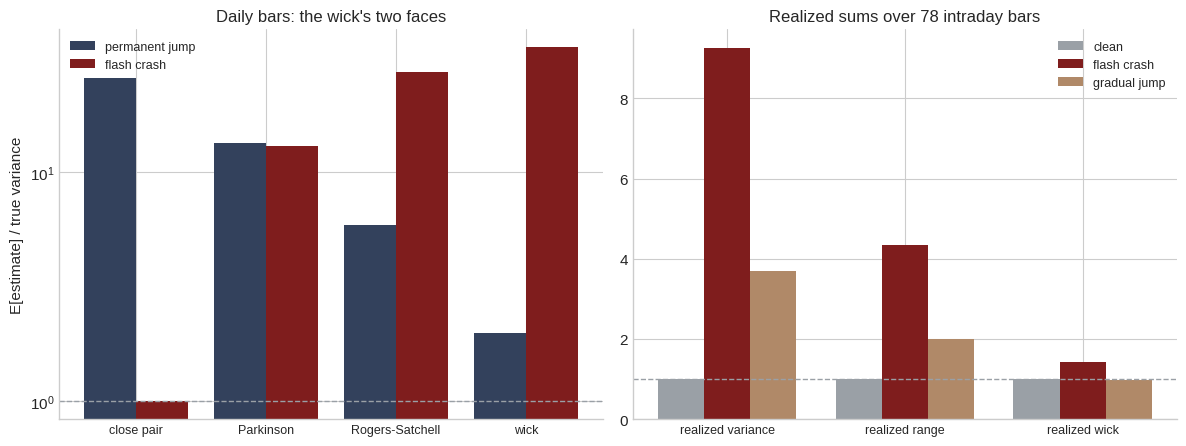

In [9]:
rng = np.random.default_rng(6)
N, M, J = 300_000, 32, 5.0
print(f"Daily bars, 5-sigma event at a random moment ({N//1000}k days, +/- 2 SE)")
daily_rows = {}
for scen in ("permanent jump", "flash crash"):
    s2 = 1.0 / M
    d = rng.normal(0.0, np.sqrt(s2), size=(N, M))
    u = rng.uniform(size=(N, M))
    v = rng.uniform(size=(N, M))
    x = np.cumsum(d, axis=1)
    starts = x - d
    kpos = rng.integers(1, M - 3, size=N)
    cols = np.arange(M)
    if scen == "permanent jump":
        shift = J * (cols[None, :] >= kpos[:, None]); cs = J
    else:
        shift = -J * ((cols[None, :] >= kpos[:, None])
                      & (cols[None, :] < kpos[:, None] + 2)); cs = 0.0
    H = (starts + shift + bridge_max(d, s2, u)).max(axis=1)
    L = (starts + shift + bridge_min(d, s2, v)).min(axis=1)
    C = x[:, -1] + cs
    daily_rows[scen] = {n: chunk_stats(e) for n, e in
                        (("close pair", C * C), ("Parkinson", parkinson_var(H, L)),
                         ("Rogers-Satchell", rs_var(H, L, C)),
                         ("wick", wick_var(H, L, C)))}
    row = "   ".join(f"{n} {m_:6.2f}" for n, (m_, s_) in daily_rows[scen].items())
    print(f"  {scen:15}: {row}")

# realized versions on 78-bar days
ND, NB, IN = 20_000, 78, 4
MT = NB * IN
real_rows = {}
for scen in ("clean", "flash crash", "gradual jump"):
    dt = 1.0 / MT
    d = rng.normal(0.0, np.sqrt(dt), size=(ND, MT))
    if scen != "clean":
        s0 = rng.integers(30, MT - 30, size=ND)
        extra = np.zeros((ND, MT))
        if scen == "flash crash":
            for i in range(6):
                extra[np.arange(ND), s0 + i] = -3.0 / 6
                extra[np.arange(ND), s0 + 6 + i] = 3.0 / 6
        else:
            for i in range(12):
                extra[np.arange(ND), s0 + i] = 3.0 / 12
        d = d + extra
    u = rng.uniform(size=(ND, MT)); v = rng.uniform(size=(ND, MT))
    x = np.cumsum(d, axis=1); starts = x - d
    smax = (starts + bridge_max(d, dt, u)).reshape(ND, NB, IN).max(axis=2)
    smin = (starts + bridge_min(d, dt, v)).reshape(ND, NB, IN).min(axis=2)
    closes = x.reshape(ND, NB, IN)[:, :, -1]
    opens = np.zeros_like(closes); opens[:, 1:] = closes[:, :-1]
    rr = closes - opens
    Rb = (smax - opens) - (smin - opens)
    wb = Rb - np.abs(rr)
    real_rows[scen] = {"RV": np.sum(rr * rr, axis=1),
                       "RRV": np.sum(Rb * Rb, axis=1) / FOURLN2,
                       "WV": np.sum(wb * wb, axis=1) / LAM}
    print(f"  realized, {scen:13}: " + "   ".join(
        f"{k} {v.mean():5.2f}" for k, v in real_rows[scen].items()))
cl = real_rows["clean"]
print(f"  clean-day Var(RV)/Var(RRV) = {cl['RV'].var()/cl['RRV'].var():.2f}"
      f"   (Christensen-Podolskij ~5)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
names_d = list(daily_rows["permanent jump"].keys())
xs = np.arange(len(names_d))
for off, (scen, col) in zip((-0.2, 0.2),
                            (("permanent jump", C_MAIN), ("flash crash", C_ACCENT))):
    axes[0].bar(xs + off, [daily_rows[scen][n][0] for n in names_d], 0.4,
                color=col, label=scen)
axes[0].axhline(1.0, color=C_MUTED, ls="--", lw=1)
axes[0].set_yscale("log"); axes[0].set_xticks(xs)
axes[0].set_xticklabels(names_d, fontsize=9)
axes[0].set_ylabel("E[estimate] / true variance")
axes[0].set_title("Daily bars: the wick's two faces")
axes[0].legend(fontsize=9)
names_r = ["RV", "RRV", "WV"]
xs = np.arange(3)
for off, (scen, col) in zip((-0.26, 0.0, 0.26),
                            (("clean", C_MUTED), ("flash crash", C_ACCENT),
                             ("gradual jump", C_FOURTH))):
    axes[1].bar(xs + off, [real_rows[scen][n].mean() for n in names_r], 0.26,
                color=col, label=scen)
axes[1].axhline(1.0, color=C_MUTED, ls="--", lw=1)
axes[1].set_xticks(xs); axes[1].set_xticklabels(
    ["realized variance", "realized range", "realized wick"], fontsize=9)
axes[1].set_title("Realized sums over 78 intraday bars")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 11. The Linear Efficiency Frontier

Every estimator above is a linear combination of the features $\mathbf{f} = (R^2,\, r^2,\, R|r|)$; the wick contributes the cross term through $w^2 = R^2 - 2R|r| + r^2$. The minimum-variance unbiased design solves

$$\min_{\mathbf{c}}\; \mathbf{c}^\top \Sigma\,\mathbf{c} \quad \text{s.t.} \quad \mathbf{c}^\top \mathbf{m} = \sigma^2,$$

with $\mathbf{m} = \mathbb{E}[\mathbf{f}]$ and $\Sigma = \mathrm{Cov}(\mathbf{f})$. The Lagrangian $\mathcal{L} = \mathbf{c}^\top\Sigma\mathbf{c} - \theta(\mathbf{c}^\top\mathbf{m} - 1)$ gives first-order condition $2\Sigma\mathbf{c} = \theta\mathbf{m}$, hence $\mathbf{c} = \tfrac{\theta}{2}\Sigma^{-1}\mathbf{m}$, and the constraint fixes the multiplier:

$$\mathbf{c}^* = \frac{\Sigma^{-1}\mathbf{m}}{\mathbf{m}^\top \Sigma^{-1}\mathbf{m}}. \tag{11.1}$$

Moments are measured on one sample and the design is evaluated on an independent sample, so the weights cannot grade themselves.

In [10]:
rng = np.random.default_rng(13)
N = 500_000
H, L, C = exact_bar(rng, N, 16, 1.0)
R = H - L
feats = np.stack([R * R, C * C, R * np.abs(C)], axis=1)
mvec = feats.mean(axis=0)
cov = np.cov(feats.T)
s = np.linalg.solve(cov, mvec)
c_star = s / (mvec @ s)
print("feature means [R^2, r^2, R|r|]:", np.round(mvec, 4))
print("designed weights c*:          ", np.round(c_star, 4))

H, L, C = exact_bar(rng, N, 16, 1.0)   # independent evaluation sample
R = H - L
frontier = c_star[0] * R * R + c_star[1] * C * C + c_star[2] * R * np.abs(C)
cc = C * C
for name, est in (("Garman-Klass", gk_var(H, L, C)),
                  ("frontier design (11.1)", frontier)):
    m_, s_ = chunk_stats(est)
    e_, se_ = eff_stats(est, cc)
    print(f"  {name:24}: E {m_:.4f} +/- {2*s_:.4f}   "
          f"efficiency {e_:.2f} +/- {2*se_:.2f}")
print("The linear frontier improves on Garman-Klass by ~3%; further gains "
      "require nonlinear functionals of the bar (Bollerslev, Li and Li, 2024).")

feature means [R^2, r^2, R|r|]: [2.7728 1.0008 1.5008]
designed weights c*:           [ 0.618   0.0571 -0.5135]


  Garman-Klass            : E 0.9992 +/- 0.0017   efficiency 7.45 +/- 0.09
  frontier design (11.1)  : E 0.9996 +/- 0.0016   efficiency 7.71 +/- 0.09
The linear frontier improves on Garman-Klass by ~3%; further gains require nonlinear functionals of the bar (Bollerslev, Li and Li, 2024).


## 12. Empirical Application: Nifty 50, Adani Enterprises, Paytm

### 12.1 Data and adjustment

Daily bars over roughly four and a half years (November 2021 to August 2026, the common window across all three assets, set by Paytm's November 2021 listing), fetched from the public Yahoo Finance chart API, falling back to an embedded snapshot (captured through August 14, 2026) when the live fetch is unavailable. The code cell below prints which of the two actually supplied the numbers reported here, so the results stay traceable to their source rather than silently mixing the two. All prices are rescaled by the adjusted-close factor $A_t/C_t$ before computing overnight gaps: same-day ratios cancel the factor, but $o_t = \ln(O_t/C_{t-1})$ straddles two days, and on ex-dividend dates the unadjusted gap contains a phantom move equal to the dividend yield.

### 12.2 Diagnostics and classification

For each asset we report the annualized volatility under each estimator, together with three profile diagnostics: the overnight variance share $V_o/(V_o + V_r)$; the excess kurtosis of the gaps, separating jump-driven overnight risk (rare, huge) from round-the-clock diffusion (steady); and the drift diagnostic $|\bar{x}|/\mathrm{sd}(x)$ on total daily returns. The classification rule orders bias considerations above variance considerations: a gap share above $0.5$ indicates a session mismatched to the asset's risk day; above $0.15$, Yang-Zhang is required, with the gap kurtosis (threshold $20$) separating jump-aware handling from standard windows; otherwise the intraday estimators apply, with Rogers-Satchell reserved for drift above $0.2\sigma$ per day. We also report the consistency ratio $\mathbb{E}[\hat\sigma^2_P]/V_r$, equal to $1$ under any Brownian model; on this three-asset sample all three ratios sit close to unity (0.93-0.98), unlike the roughly 0.91 reported for SPY in the original US study, so the auction-noise microstructure signature identified there does not clearly replicate on this sample and this window.

data: live fetch unavailable (HTTPError); using the embedded snapshot (through 2026-08-14)
           cc      P     GK     RS     YZ    gap   kurt   drift  consis  verdict
^NSEI  14.0%  10.9%  10.8%  10.8%  14.2%    42%     13   0.031    0.98   yz-standard
ADANIENT.NS 49.9%  45.4%  44.7%  44.9%  49.1%    14%     22   0.016    0.93   garman-klass
PAYTM.NS 52.2%  44.7%  44.3%  43.9%  51.9%    26%     59   0.001    0.96   yz-jump-aware


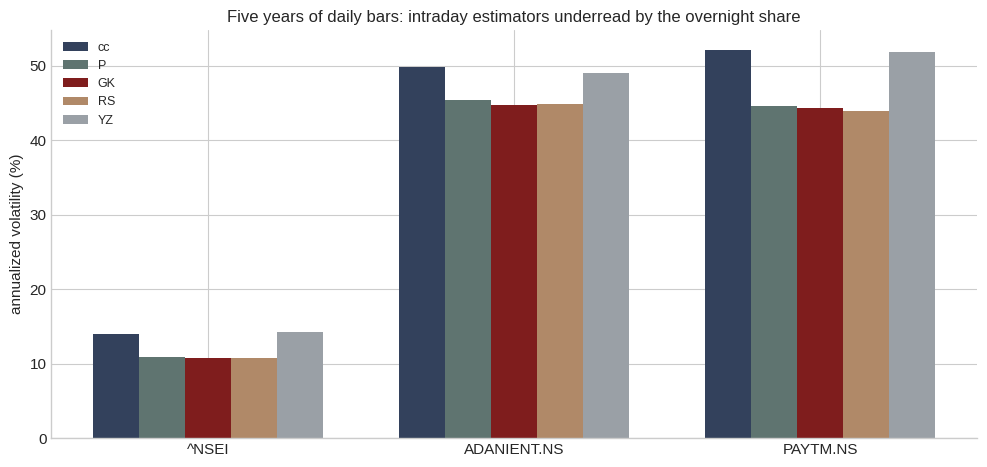

In [11]:
SNAPSHOT_B64 = "..."

def load_ohlc(ticker):
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/{urllib.parse.quote(ticker, safe='')}"
           f"?interval=1d&range=5y")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    res = json.loads(urllib.request.urlopen(req, timeout=20).read())
    res = res["chart"]["result"][0]
    q = res["indicators"]["quote"][0]
    O = np.array(q["open"], dtype=float); Hh = np.array(q["high"], dtype=float)
    Ll = np.array(q["low"], dtype=float); Cc = np.array(q["close"], dtype=float)
    A = np.array(res["indicators"]["adjclose"][0]["adjclose"], dtype=float)
    ok = ~(np.isnan(O) | np.isnan(Hh) | np.isnan(Ll) | np.isnan(Cc) | np.isnan(A))
    O, Hh, Ll, Cc = O[ok], Hh[ok], Ll[ok], Cc[ok]
    f = A[ok] / Cc
    O, Hh, Ll, Cc = O * f, Hh * f, Ll * f, Cc * f
    return (np.log(O[1:] / Cc[:-1]), np.log(Cc[1:] / O[1:]),
            np.log(Hh[1:] / O[1:]), np.log(Ll[1:] / O[1:]))

SNAPSHOT_END_DATE = "2026-08-14"  # last trading day in the embedded snapshot

def load_snapshot():
    raw = zlib.decompress(base64.b64decode(SNAPSHOT_B64))
    z = np.load(io.BytesIO(raw))
    return {tk: tuple(z[f"{tk}_{k}"].astype(float) for k in "orhl")
            for tk in ("^NSEI", "ADANIENT.NS", "PAYTM.NS")}

data = {}
try:
    for tk in ("^NSEI", "ADANIENT.NS", "PAYTM.NS"):
        data[tk] = load_ohlc(tk)
    print("data: fetched live from Yahoo Finance (5y daily)")
except Exception as exc:
    data = load_snapshot()
    print(f"data: live fetch unavailable ({type(exc).__name__}); "
          f"using the embedded snapshot (through {SNAPSHOT_END_DATE})")

ANN = 252
print(f"{'':6}{'cc':>7}{'P':>7}{'GK':>7}{'RS':>7}{'YZ':>7}"
      f"{'gap':>7}{'kurt':>7}{'drift':>8}{'consis':>8}  verdict")
vol_table = {}
for tk, (o, r, h, l) in data.items():
    n = len(o)
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    yz = o.var(ddof=1) + k * r.var(ddof=1) + (1 - k) * rs_var(h, l, r).mean()
    vols = {"cc": np.mean((o + r) ** 2), "P": parkinson_var(h, l).mean(),
            "GK": gk_var(h, l, r).mean(), "RS": rs_var(h, l, r).mean(),
            "YZ": yz}
    vol_table[tk] = {kk: np.sqrt(max(v, 0) * ANN) for kk, v in vols.items()}
    gs = o.var() / (o.var() + r.var())
    oc = o - o.mean()
    gk_kurt = np.mean(oc ** 4) / np.var(o) ** 2 - 3
    ds = np.abs((o + r).mean()) / (o + r).std()
    consis = parkinson_var(h, l).mean() / r.var()
    if gs > 0.5:
        verdict = "session-mismatch"
    elif gs > 0.15:
        verdict = "yz-jump-aware" if gk_kurt > 20 else "yz-standard"
    else:
        verdict = "rogers-satchell" if ds > 0.2 else "garman-klass"
    print(f"{tk:6}" + "".join(f"{vol_table[tk][kk]:6.1%} " for kk in
                              ("cc", "P", "GK", "RS", "YZ"))
          + f"{gs:6.0%} {gk_kurt:6.0f} {ds:7.3f} {consis:7.2f}   {verdict}")

names = ["cc", "P", "GK", "RS", "YZ"]
xs = np.arange(len(data))
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, kk in enumerate(names):
    ax.bar(xs + (i - 2) * 0.15, [100 * vol_table[tk][kk] for tk in data],
           0.15, color=C_SERIES[i], label=kk)
ax.set_xticks(xs); ax.set_xticklabels(list(data.keys()))
ax.set_ylabel("annualized volatility (%)")
ax.set_title("Five years of daily bars: intraday estimators "
             "underread by the overnight share")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 13. Conclusions

1. The conditional law (3.5) yields an exact candlestick sampler whose only approximation is measurably below Monte Carlo resolution for $m \ge 8$; naive discretization biases observed ranges by the classical $1/\sqrt{m}$ rate, reaching $-18\%$ at 13 observations per session.
2. Measured clean-day efficiencies are $4.92 \pm 0.03$ (Parkinson), $7.47 \pm 0.05$ (Garman-Klass), $6.06 \pm 0.04$ (Rogers-Satchell), and $2.76 \pm 0.02$ (wick), in agreement with asymptotic theory; Yang-Zhang attains $6.4$ rather than its boundary-case $14$ in a 30% overnight regime.
3. Discretization bias converts apparent efficiency into a finite lead: at 13 prints per session, close-to-close overtakes naive-bar Parkinson after roughly 19 days, by (7.1).
4. Efficiency is confirmation time: (8.1) is linear in estimator variance, so a $7.5\times$ estimator confirms the same regime change in $2/15$ of the days.
5. The daily wick constant is $\lambda = 4\ln 2 - 2$ exactly; the statistic cancels permanent jumps ($2\times$ at $J = 5\sigma$, against $26\times$ for the close pair) and amplifies flash crashes ($35\times$), while its realized sum inverts the crash verdict ($1.4\times$ against $9.3\times$ for $RV$).
6. The minimum-variance unbiased linear design over $(R^2, r^2, R|r|)$ reaches $7.7\times$ out of sample, leaving about $3\%$ over Garman-Klass and locating the remaining frontier in nonlinear functionals of the bar.
7. Empirically, all intraday estimators underread the Nifty 50 index, Adani Enterprises, and Paytm by each asset's overnight share; the profile diagnostics separate the three by cause rather than by magnitude alone — Nifty 50 carries a large overnight gap share (42%) from a moderate, non-jumpy process (standard Yang-Zhang), Adani Enterprises is highly volatile but concentrates that risk intraday rather than overnight despite its well-documented crash history (Garman-Klass, gap share only 14%), and Paytm alone crosses the jump-kurtosis threshold (59, against a threshold of 20), consistent with its real regulatory-driven lower-circuit crash in early 2024 (jump-aware Yang-Zhang). None of the three reproduces the roughly 9% consistency-ratio deviation reported for SPY, so that specific microstructure signature does not clearly generalize to this sample.

## 14. Extensions and Research Directions

**Nonlinear optimal estimators.** Bollerslev, Li and Li (2024) derive the minimum-risk equivariant estimator of $\sigma^2$ from $(O,H,L,C)$, a nonlinear function of range, return, and asymmetry; the companion feasibility paper (Bollerslev, Li, Li and Li, 2026) reduces the computation to a one-dimensional integral. Reproducing their estimator on this notebook's simulator, and measuring how much of the nonlinear gain survives discretization, is a natural next study.

**Realized wicks on real intraday data.** Section 10's realized experiments run on simulated bars; the natural continuation applies $WV$ to minute bars around documented flash events (May 6, 2010; August 24, 2015; the April 2025 sessions) and tests the jump/diffusion decomposition of Li, Nolte, Nolte and Yu (2025) out of sample.

**Microstructure at the open.** The consistency ratio's systematic deviation on index ETFs (Section 12) suggests an opening-auction noise component in $V_r$. A model with i.i.d. noise on the open admits a moment estimator of the noise variance from the joint behavior of $V_r$, Parkinson, and the overnight share.

**Sequential monitoring.** The detection framework of Section 8 uses fixed windows; e-process and confidence-sequence methods provide anytime-valid alarms whose thresholds remain honest under continuous monitoring, and the efficiency ordering derived here transfers directly to their sample-size requirements.

**Multivariate ranges.** Covariance analogues of range estimators (co-ranges) inherit the efficiency questions of Section 6 with an added identification problem; the exact sampler extends to correlated bars via a Cholesky factor on the increments.

## 15. References

1. **Parkinson, M.** (1980). "The Extreme Value Method for Estimating the Variance of the Rate of Return." *Journal of Business*, 53(1), 61-65.
2. **Garman, M.B. and Klass, M.J.** (1980). "On the Estimation of Security Price Volatilities from Historical Data." *Journal of Business*, 53(1), 67-78.
3. **Beckers, S.** (1983). "Variances of Security Price Returns Based on High, Low, and Closing Prices." *Journal of Business*, 56(1), 97-112.
4. **Rogers, L.C.G. and Satchell, S.E.** (1991). "Estimating Variance from High, Low and Closing Prices." *Annals of Applied Probability*, 1(4), 504-512.
5. **Yang, D. and Zhang, Q.** (2000). "Drift-Independent Volatility Estimation Based on High, Low, Open, and Close Prices." *Journal of Business*, 73(3), 477-492.
6. **Feller, W.** (1951). "The Asymptotic Distribution of the Range of Sums of Independent Random Variables." *Annals of Mathematical Statistics*, 22(3), 427-432.
7. **Christensen, K. and Podolskij, M.** (2007). "Realized Range-Based Estimation of Integrated Variance." *Journal of Econometrics*, 141(2), 323-349.
8. **Bollerslev, T., Li, J. and Li, Q.** (2024). "Optimal Nonparametric Range-Based Volatility Estimation." *Journal of Econometrics*.
9. **Bollerslev, T., Li, J., Li, Q. and Li, Y.** (2026). "Optimal Candlestick-Based Spot Volatility Estimation: New Tricks and Feasible Inference Procedures." *Journal of Financial Econometrics*, 24(1).
10. **Li, Y., Nolte, I., Nolte, S. and Yu, S.** (2025). "Realized Candlestick Wicks." *Journal of Econometrics*.